# Задача 9. Hand-crafted graph features

* **Дедлайн**: 16.05.2025, 23:59
* Основной полный балл: 5
* Максимум баллов: 10


## Задача

- Найти или сгенерировать набор данных для бинарной классификации графов.
- Реализовать функцию `shortest_path_kernel(train_graphs, test_graphs)`, которая принимает тренировочный и тестовые наборы, а возвращает пару `K_train, K_test`
  - Опишите графы с помощью вектора из количества кратчайших путей различной длины
  - Для вычисления длин кратчайших путей можно использовать `nx.shortest_path_length(G)`
  - Ядровая функция для сравнения двух графов - скалярное произведение их двух векторов
  - `K_train` - матрица из ядровых функций для сравнения тренировочных графов между собой
  - `K_test` - матрица из ядровых функций для сравнения тестовых графов с тренировочными
- Используя реализованное ядро обучите модель SVC, подберите гиперпараметры, вычислите различные метрики качества
- (+5 баллов) Также реализовать Weisfeiler-Lehman Kernel и обучить классификатор с ним, сравнить результаты.

In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, classification_report
import random
from collections import Counter
import tqdm
import itertools
import pandas as pd

## Датасет

Для начала сгенерируем набор графов двух классов:
- граф планарный (его можно нарисовать на плоскости без пересечений рёбер)
- граф непланарный

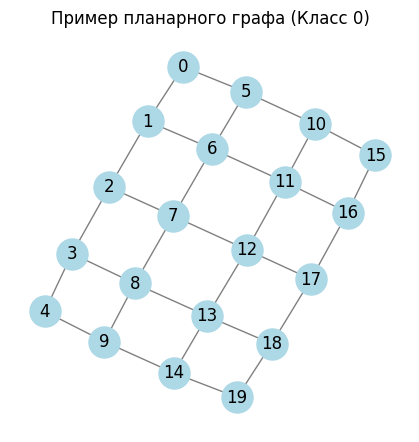

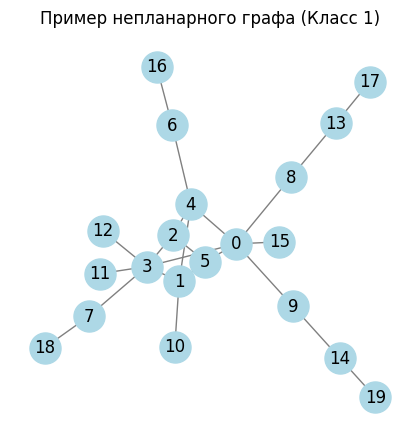

In [42]:
def generate_planar_graph(n):
    # Дерево (всегда планарно)
    if random.random() < 0.5:
        G = nx.random_tree(n)
    # Планарный граф с циклами
    else:
        rows = int(n**0.5)
        cols = (n + rows - 1) // rows
        G = nx.grid_2d_graph(rows, cols)
        G = nx.convert_node_labels_to_integers(G) 
        while G.number_of_nodes() > n:
            G.remove_node(G.number_of_nodes() - 1)
    return G

def generate_non_planar_graph(n):
    # Полный граф K5
    if n >= 5 and random.random() < 0.5:
        G = nx.complete_graph(5)
        for i in range(5, n):
            G.add_node(i)
            parent = random.choice(list(G.nodes())[:i])
            G.add_edge(i, parent)
    # Полный двудольный граф K3,3
    else:
        G = nx.complete_bipartite_graph(3, 3)
        for i in range(6, n):
            G.add_node(i)
            parent = random.choice(list(G.nodes())[:i])
            G.add_edge(i, parent)
    return G

def generate_graph_dataset(n_graphs=100, min_nodes=10, max_nodes=20, seed=42):
    random.seed(seed)
    
    graphs = []
    labels = []  # 0 -- планарный, 1 -- непланарный
    
    for _ in range(n_graphs):
        n = random.randint(min_nodes, max_nodes)
        
        if random.random() < 0.5:
            # Планарный граф
            G = generate_planar_graph(n)
            label = 0
        else:
            # Непланарный граф
            G = generate_non_planar_graph(n)
            label = 1
            
        graphs.append(G)
        labels.append(label)
    
    return graphs, labels

graphs, labels = generate_graph_dataset(n_graphs=1000)

def draw_graph(G, title):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(4, 4))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)
    plt.title(title)
    plt.show()

tree_graph = None
cyclic_graph = None

for g, label in zip(graphs, labels):
    if label == 0 and tree_graph is None:
        tree_graph = g
    elif label == 1 and cyclic_graph is None:
        cyclic_graph = g
    if tree_graph and cyclic_graph:
        break

draw_graph(tree_graph, title="Пример планарного графа (Класс 0)")
draw_graph(cyclic_graph, title="Пример непланарного графа (Класс 1)")

Разделим набор данных на train/test

In [43]:
train_graphs, test_graphs, y_train, y_test = train_test_split(graphs, labels, test_size=0.3, random_state=42, stratify=labels)

## Реализация функции `shortest_path_kernel`

In [50]:
def graph_to_shortest_path_vector(G, max_path_length=10):
    path_length_counts = Counter()
    
    lengths = dict(nx.shortest_path_length(G))
    
    for source in lengths:
        for target in lengths[source]:
            if source < target:
                d = lengths[source][target]
                if d <= max_path_length:
                    path_length_counts[d] += 1
                    
    vector = np.array([path_length_counts.get(i, 0) for i in range(1, max_path_length + 1)])
    return vector

def shortest_path_kernel(train_graphs, test_graphs, max_path_length=10):
    X_train = np.array([graph_to_shortest_path_vector(g, max_path_length) for g in train_graphs])
    X_test = np.array([graph_to_shortest_path_vector(g, max_path_length) for g in test_graphs])
    
    K_train = X_train @ X_train.T
    K_test = X_test @ X_train.T
    
    return K_train, K_test

## Обучение

In [51]:
K_train, K_test = shortest_path_kernel(train_graphs, test_graphs)

In [52]:
svc = SVC(kernel="precomputed", random_state=42)
svc.fit(K_train, y_train)
y_pred = svc.predict(K_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.7241    0.9304    0.8144       158
           1     0.8866    0.6056    0.7197       142

    accuracy                         0.7767       300
   macro avg     0.8054    0.7680    0.7670       300
weighted avg     0.8010    0.7767    0.7696       300



### Подбор гиперпараметров

Подберем длину пути и регуляризационный параметр C

100%|██████████| 35/35 [01:39<00:00,  2.85s/it]

Лучший набор: {'max_path_len': 6.0, 'C': 0.1, 'accuracy': 0.7933333333333333, 'precision': 0.9166666666666666}


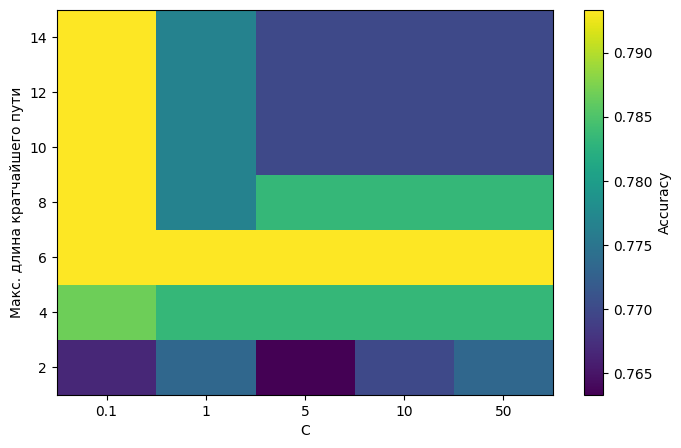

In [ ]:
PATH_RANGE   = [2, 4, 6, 8, 10, 12, 14]
C_VALUES     = [0.1, 1, 5, 10, 50]

path_accuracy = []


for L, C in tqdm.tqdm(list(itertools.product(PATH_RANGE, C_VALUES))):
    
    K_tr, K_val = shortest_path_kernel(train_graphs, test_graphs, max_path_length=L)
    
    svc = SVC(kernel="precomputed", C=C, random_state=42)
    svc.fit(K_tr, y_train)
    y_pred = svc.predict(K_val)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    path_accuracy.append({"max_path_len": L, "C": C, "accuracy": accuracy, "precision": precision})

df = pd.DataFrame(path_accuracy)
best_row = df.loc[df.accuracy.idxmax()]
print("Лучший набор:", best_row.to_dict())


pivot = df.pivot(index="max_path_len", columns="C", values="accuracy")
plt.figure(figsize=(8, 5))
plt.imshow(pivot, cmap="viridis", origin="lower", aspect="auto")
plt.colorbar(label="Accuracy")
plt.xticks(ticks=np.arange(len(C_VALUES)), labels=C_VALUES)
plt.yticks(ticks=np.arange(len(PATH_RANGE)), labels=PATH_RANGE)
plt.xlabel("C")
plt.ylabel("Макс. длина кратчайшего пути")
plt.show()

## Реализация Weisfeiler-Lehman Kernel

In [ ]:
def wl_subtree_features(G, h=3):
    labels = {v: str(G.nodes[v].get("label", G.degree(v))) for v in G.nodes}
    features = Counter(labels.values())

    for _ in range(h):
        new_labels = {}
        for v in G.nodes:
            neigh_lab = sorted(labels[u] for u in G.neighbors(v))
            new_lab = labels[v] + "|" + "|".join(neigh_lab)
            new_labels[v] = new_lab
        labels = new_labels
        features.update(labels.values())

    return features

def wl_kernel(train_graphs, test_graphs, h=3):
    f_train = [wl_subtree_features(g, h) for g in train_graphs]
    f_test  = [wl_subtree_features(g, h) for g in test_graphs]

    vocab = {}
    for D in f_train + f_test:
        for lab in D:
            if lab not in vocab:
                vocab[lab] = len(vocab)
    dim = len(vocab)

    def dict2vec(D):
        v = np.zeros(dim, dtype=np.float32)
        for lab, cnt in D.items():
            v[vocab[lab]] = cnt
        return v

    X_train = np.stack([dict2vec(D) for D in f_train])
    X_test = np.stack([dict2vec(D) for D in f_test])

    K_train = X_train @ X_train.T
    K_test = X_test @ X_train.T
    return K_train, K_test

K_train, K_test = wl_kernel(train_graphs, test_graphs)
svc = SVC(kernel="precomputed", random_state=42)
svc.fit(K_train, y_train)
y_pred = svc.predict(K_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9935    0.9684    0.9808       158
           1     0.9658    0.9930    0.9792       142

    accuracy                         0.9800       300
   macro avg     0.9796    0.9807    0.9800       300
weighted avg     0.9804    0.9800    0.9800       300



## Результаты

Weisfeiler–Lehman subtree kernel способен захватывать более глубокие структурные различия между графами за счёт итеративного учёта контекста окрестностей вершин. Это делает его особенно эффективным в задачах, где топологическая структура графа играет ключевую роль — например, при классификации планарных и непланарных графов. Классические непланарные графы, такие как K_5 или K_{3,3}, обладают характерной структурной сложностью, которую `wl_kernel` способен более точно уловить по сравнению с ядром кратчайших путей (`shortest_path_kernel`). В результате, даже без подбора гиперпараметров, `wl_kernel` демонстрирует ощутимое преимущество на подобных задачах.